In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print("Libraries load ho gayi!")

Libraries load ho gayi!


In [2]:
URL = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

print("Data download ho raha hai... thoda wait karo")
df_raw = pd.read_csv(URL)
print(f"Raw data loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")

Data download ho raha hai... thoda wait karo
Raw data loaded: 429,435 rows, 67 columns


In [3]:
df = df_raw[df_raw['location'] == 'Pakistan'].copy()
df = df.reset_index(drop=True)
print(f"Pakistan data: {len(df)} rows")

Pakistan data: 1674 rows


In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Date range: 2020-01-05 to 2024-08-04


In [5]:
cols_needed = [
    'date',
    'new_cases',
    'new_deaths',
    'total_cases',
    'total_deaths',
    'total_vaccinations',
    'people_vaccinated',
    'people_fully_vaccinated',
    'positive_rate',
    'population'
]

cols_available = [c for c in cols_needed if c in df.columns]
df = df[cols_available].copy()
print(f"Columns selected: {len(cols_available)}")
print(cols_available)

Columns selected: 10
['date', 'new_cases', 'new_deaths', 'total_cases', 'total_deaths', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'positive_rate', 'population']


In [6]:
print("--- Missing Values Report ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

for col in df.columns:
    print(f"{col}: {missing[col]} missing ({missing_pct[col]}%)")

--- Missing Values Report ---
date: 0 missing (0.0%)
new_cases: 0 missing (0.0%)
new_deaths: 0 missing (0.0%)
total_cases: 0 missing (0.0%)
total_deaths: 0 missing (0.0%)
total_vaccinations: 1292 missing (77.2%)
people_vaccinated: 1305 missing (78.0%)
people_fully_vaccinated: 1382 missing (82.6%)
positive_rate: 846 missing (50.5%)
population: 0 missing (0.0%)


In [7]:
# Cases aur deaths: NaN ko 0 se replace karo
for col in ['new_cases', 'new_deaths']:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        df[col] = df[col].clip(lower=0)

# Total columns: forward fill karo
for col in ['total_cases', 'total_deaths',
            'total_vaccinations', 'people_vaccinated',
            'people_fully_vaccinated']:
    if col in df.columns:
        df[col] = df[col].ffill().fillna(0)

# Positive rate: interpolate karo
if 'positive_rate' in df.columns:
    df['positive_rate'] = df['positive_rate'].interpolate(method='linear').fillna(0)

print("Missing values fix ho gayi!")
print(f"Remaining missing: {df.isnull().sum().sum()}")

Missing values fix ho gayi!
Remaining missing: 0


In [8]:
df['cases_7day_avg'] = df['new_cases'].rolling(window=7, min_periods=1).mean().round(0)
df['deaths_7day_avg'] = df['new_deaths'].rolling(window=7, min_periods=1).mean().round(2)

print("7-day rolling averages ban gayi!")
print(df[['date', 'new_cases', 'cases_7day_avg']].tail(7))

7-day rolling averages ban gayi!
           date  new_cases  cases_7day_avg
1667 2024-07-29        0.0             0.0
1668 2024-07-30        0.0             0.0
1669 2024-07-31        0.0             0.0
1670 2024-08-01        0.0             0.0
1671 2024-08-02        0.0             0.0
1672 2024-08-03        0.0             0.0
1673 2024-08-04        0.0             0.0


In [9]:
# Case fatality rate
df['case_fatality_rate'] = (
    df['total_deaths'] / df['total_cases'].replace(0, np.nan) * 100
).round(2)

# Vaccination coverage %
if 'people_fully_vaccinated' in df.columns:
    df['vaccination_coverage_pct'] = (
        df['people_fully_vaccinated'] / df['population'] * 100
    ).round(2)

# Month aur Year
df['year'] = df['date'].dt.year
df['month_name'] = df['date'].dt.strftime('%b %Y')

# Wave labels
def get_wave(date):
    if date < pd.Timestamp('2020-07-01'):
        return 'Wave 1'
    elif date < pd.Timestamp('2020-12-01'):
        return 'Wave 2'
    elif date < pd.Timestamp('2021-05-01'):
        return 'Wave 3'
    elif date < pd.Timestamp('2021-11-01'):
        return 'Wave 4'
    elif date < pd.Timestamp('2022-04-01'):
        return 'Wave 5 (Omicron)'
    else:
        return 'Post-Peak'

df['wave'] = df['date'].apply(get_wave)

print("Extra columns add ho gayi!")
print(f"Total columns ab: {len(df.columns)}")
print(list(df.columns))

Extra columns add ho gayi!
Total columns ab: 17
['date', 'new_cases', 'new_deaths', 'total_cases', 'total_deaths', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'positive_rate', 'population', 'cases_7day_avg', 'deaths_7day_avg', 'case_fatality_rate', 'vaccination_coverage_pct', 'year', 'month_name', 'wave']


In [10]:
df.to_csv('pakistan_covid_clean.csv', index=False)
print("File save ho gayi: pakistan_covid_clean.csv")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total cases: {int(df['total_cases'].max()):,}")
print(f"Total deaths: {int(df['total_deaths'].max()):,}")

File save ho gayi: pakistan_covid_clean.csv
Total rows: 1,674
Total columns: 17
Date range: 2020-01-05 to 2024-08-04
Total cases: 1,580,631
Total deaths: 30,656


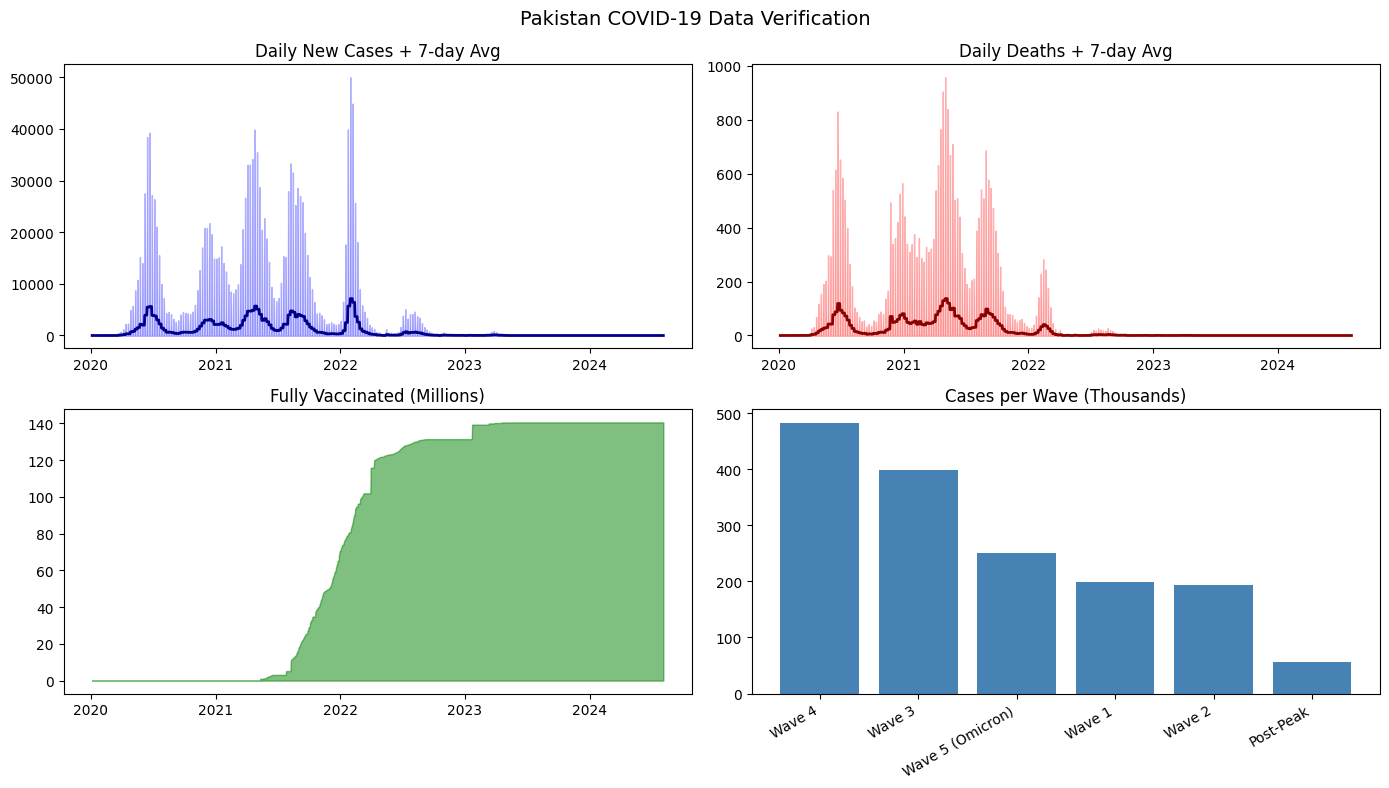

Charts ban gayi!


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Pakistan COVID-19 Data Verification', fontsize=14)

# Chart 1: Daily cases
axes[0,0].fill_between(df['date'], df['new_cases'], alpha=0.3, color='blue')
axes[0,0].plot(df['date'], df['cases_7day_avg'], color='darkblue', linewidth=2)
axes[0,0].set_title('Daily New Cases + 7-day Avg')

# Chart 2: Daily deaths
axes[0,1].fill_between(df['date'], df['new_deaths'], alpha=0.3, color='red')
axes[0,1].plot(df['date'], df['deaths_7day_avg'], color='darkred', linewidth=2)
axes[0,1].set_title('Daily Deaths + 7-day Avg')

# Chart 3: Vaccination
axes[1,0].fill_between(df['date'], df['people_fully_vaccinated']/1e6, alpha=0.5, color='green')
axes[1,0].set_title('Fully Vaccinated (Millions)')

# Chart 4: Cases per wave
wave_data = df.groupby('wave')['new_cases'].sum().sort_values(ascending=False)
axes[1,1].bar(range(len(wave_data)), wave_data.values/1000, color='steelblue')
axes[1,1].set_xticks(range(len(wave_data)))
axes[1,1].set_xticklabels(wave_data.index, rotation=30, ha='right')
axes[1,1].set_title('Cases per Wave (Thousands)')

plt.tight_layout()
plt.savefig('covid19_verification.png', dpi=150)
plt.show()
print("Charts ban gayi!")